In [2]:
import os
import re
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
%matplotlib inline


# Load Datasets

#### Load other test datasets (datasets 2, 3 and 4): (to test how well model generalizes on arabic tweets/short text)
| Dataset | is_dialectical | is_MSA (Modern Standard Arabic) | is_balanced
| :---: | :---: | :---: | :---: |
|[SS2030](https://www.kaggle.com/snalyami3/arabic-sentiment-analysis-dataset-ss2030-dataset ) | Yes - Saudi dialect only |   No/Minority | Yes
|[100k Arabic Reviews](https://www.kaggle.com/abedkhooli/arabic-100k-reviews ) | No/Minority | Yes | Yes
| [ArSAS](https://homepages.inf.ed.ac.uk/wmagdy/resources.htm) | Yes - mixed dialects| No/Minority | Yes

In [13]:
pd.set_option('display.max_colwidth', 280)
train_neg = pd.read_csv("../input/arabic-sentiment-twitter-corpus/train_Arabic_tweets_negative_20190413.tsv", sep="\t", header=None,  quoting=csv.QUOTE_NONE)
train_neg.rename(columns={0:'label', 1:'tweet'}, inplace=True)
train_neg['label'] = 0

train_pos = pd.read_csv("../input/arabic-sentiment-twitter-corpus/train_Arabic_tweets_positive_20190413.tsv", sep="\t", header=None,  quoting=csv.QUOTE_NONE)
train_pos.rename(columns={0:'label', 1:'tweet'}, inplace=True)
train_pos['label'] = 1


train_df = pd.concat([train_neg, train_pos], axis=0).reset_index(drop=True)


from sklearn.model_selection import train_test_split
X = train_df.tweet.values
y = train_df.label.values

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.1, random_state=2020)
test_pos = pd.read_csv("../input/arabic-sentiment-twitter-corpus/test_Arabic_tweets_positive_20190413.tsv", sep="\t", header=None,  quoting=csv.QUOTE_NONE)
test_pos.rename(columns={0:'label', 1:'tweet'}, inplace=True)
test_pos['label']=1

test_neg = pd.read_csv("../input/arabic-sentiment-twitter-corpus/test_Arabic_tweets_negative_20190413.tsv", sep="\t", header=None,  quoting=csv.QUOTE_NONE)
test_neg.rename(columns={0:'label', 1:'tweet'}, inplace=True)
test_neg['label']=0

test_df = pd.concat([test_neg, test_pos], axis=0).reset_index(drop=True)
X_test = test_df.tweet.values
y_test = test_df.label.values


In [14]:
df_ss2030 = pd.read_csv("../input/arabic-sentiment-analysis-dataset-ss2030-dataset/Arabic Sentiment Analysis Dataset - SS2030.csv")
df_ss2030 = df_ss2030.rename(columns = {"text":"tweet", "Sentiment": "label"})

In [15]:
df_reviews = pd.read_csv("../input/arabic-100k-reviews/ar_reviews_100k.tsv", delimiter="\t")
label_mapping = {"Positive": 1, "Negative":0}
df_reviews = df_reviews[df_reviews.label != "Mixed"]
df_reviews["label"] = df_reviews["label"].map(label_mapping)
df_reviews = df_reviews.rename(columns = {"text":"tweet"})

In [16]:
df_arsas = pd.read_csv('../input/arsas-dataset/ArSAS..txt', header = 0, delimiter = "\t")
# Filter to only have pos and neg tweets, i.e: remove mixed tweets
df_arsas_pos = df_arsas[df_arsas.Sentiment_label == 'Positive'] 
df_arsas_neg = df_arsas[df_arsas.Sentiment_label == 'Negative'] 
df_arsas = pd.concat([df_arsas_pos, df_arsas_neg], axis=0).reset_index(drop=True)
label_mapping = {"Positive": int(1), "Negative":int(0)}
df_arsas["Sentiment_label"] = df_arsas["Sentiment_label"].map(label_mapping)
df_arsas = df_arsas.rename(columns = {"Tweet_text":"tweet", "Sentiment_label":"label"})

In [17]:
# Concatenate all of the tweets from arabic-sentiment-twitter-corpus to treat it as 1 test dataset
df_twitter_corpus = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# Dataset analysis

### Count of tweets that contain emojis 
*(models can overfit to emojis)*

In [18]:
from emoji import UNICODE_EMOJI
def contains_emoji(s):
    words = s.split(" ")
    
    for word in words:
        if word in UNICODE_EMOJI['en']:
            return True
    return False

In [19]:
def get_emoji_count(tweets, dataset_name):
    count = 0
    for tweet in tweets:
        if contains_emoji(tweet):
            count += 1
    print(f"Total number of tweets containing emojis in {dataset_name} is: {count} ,i.e {count/len(tweets)} % of total")
    

In [20]:
get_emoji_count(df_twitter_corpus.tweet, "arabic-sentiment-twitter-corpus")
get_emoji_count(df_ss2030.tweet, "SS2030")
get_emoji_count(df_reviews.tweet, "100k reviews")
get_emoji_count(df_arsas.tweet, "ArSAS")

Total number of tweets containing emojis in arabic-sentiment-twitter-corpus is: 46682 ,i.e 0.7945737093836701 % of total
Total number of tweets containing emojis in SS2030 is: 265 ,i.e 0.062323612417685796 % of total
Total number of tweets containing emojis in 100k reviews is: 0 ,i.e 0.0 % of total
Total number of tweets containing emojis in ArSAS is: 836 ,i.e 0.07094365241004752 % of total


*We can see that dataset 1 has significantly more emojis than any of the other datasets*

### Vocabulary Analysis

In [21]:
from collections import Counter
def create_word_counts(texts):
    word_counter = Counter()
    for s in texts:
        word_counter.update(s.split())
    return word_counter

In [46]:
counts_twitter_corpus = create_word_counts(df_twitter_corpus.tweet)
twitter_corpus_vocab = set(counts_twitter_corpus.keys())
counts_ss2030 = create_word_counts(df_ss2030.tweet)
ss2030_vocab = set(counts_ss2030.keys())
counts_reviews = create_word_counts(df_reviews.tweet)
reviews_vocab = set(counts_reviews.keys())
counts_arsas = create_word_counts(df_arsas.tweet)
arsas_vocab = set(counts_arsas.keys())
print(f"twitter corpus vocab length: {len(twitter_corpus_vocab)}")
print(f"ss2030 vocab length: {len(ss2030_vocab)}")
print(f"100 reviews vocab length: {len(reviews_vocab)}")
print(f"ArSAS vocab length: {len(arsas_vocab)}")

twitter corpus vocab length: 95057
ss2030 vocab length: 29823
100 reviews vocab length: 325787
ArSAS vocab length: 66388


### Finding Intersection Over Union (IOU) of the dataset's vocabularies

In [23]:
def get_iou(vocab1, vocab2):
    i = len(vocab1.intersection(vocab2))
    u = len(vocab1.union(vocab2))
    return round(i/u,2)

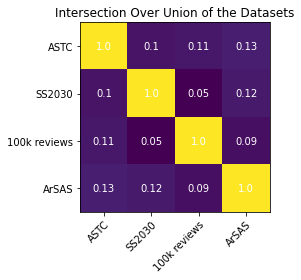

In [24]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

datasets = ["ASTC", "SS2030", "100k reviews", "ArSAS"]

ious = np.array([[get_iou(twitter_corpus_vocab,twitter_corpus_vocab), get_iou(twitter_corpus_vocab,ss2030_vocab), get_iou(twitter_corpus_vocab,reviews_vocab), get_iou(twitter_corpus_vocab,arsas_vocab)],
                [get_iou(twitter_corpus_vocab,ss2030_vocab), get_iou(ss2030_vocab,ss2030_vocab), get_iou(ss2030_vocab,reviews_vocab), get_iou(ss2030_vocab,arsas_vocab)],
                [get_iou(reviews_vocab,twitter_corpus_vocab), get_iou(reviews_vocab,ss2030_vocab), get_iou(reviews_vocab,reviews_vocab), get_iou(reviews_vocab,arsas_vocab)],
                [get_iou(arsas_vocab,twitter_corpus_vocab), get_iou(arsas_vocab,ss2030_vocab), get_iou(arsas_vocab,reviews_vocab), get_iou(arsas_vocab,arsas_vocab)]])


fig, ax = plt.subplots()
im = ax.imshow(ious)

# We want to show all ticks...
ax.set_xticks(np.arange(len(datasets)))
ax.set_yticks(np.arange(len(datasets)))
# ... and label them with the respective list entries
ax.set_xticklabels(datasets)
ax.set_yticklabels(datasets)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(len(datasets)):
    for j in range(len(datasets)):
        text = ax.text(j, i, ious[i, j],
                       ha="center", va="center", color="w")

ax.set_title("Intersection Over Union of the Datasets")
fig.tight_layout()
plt.show()

### Comparing vocabulary histograms

In [44]:
pip install arabic_reshaper

Note: you may need to restart the kernel to use updated packages.


In [67]:
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
from collections import OrderedDict
def get_vocab_histogram(dataset_counter):
    f, ax = plt.subplots(figsize=(18,5))
    counter = OrderedDict(dataset_counter.most_common(50))
    x = list(counter.keys())
    x = list(map(lambda word :get_display(arabic_reshaper.reshape(word)), x))
    y = list(counter.values())
    ax.tick_params(axis='x', labelrotation = 45)
    plt.bar(x, y, width=0.2)

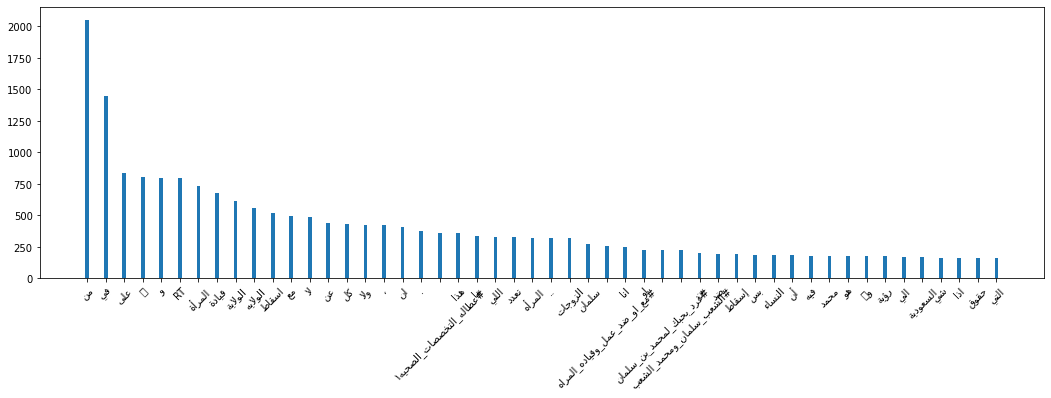

In [68]:
get_vocab_histogram(counts_ss2030)

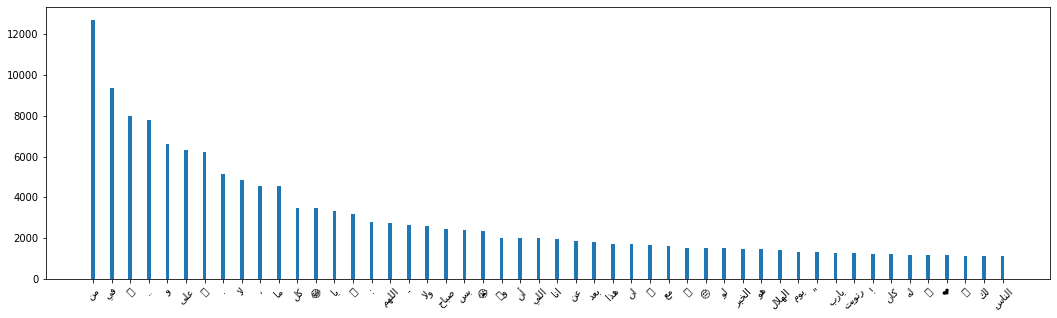

In [69]:
get_vocab_histogram(counts_twitter_corpus)

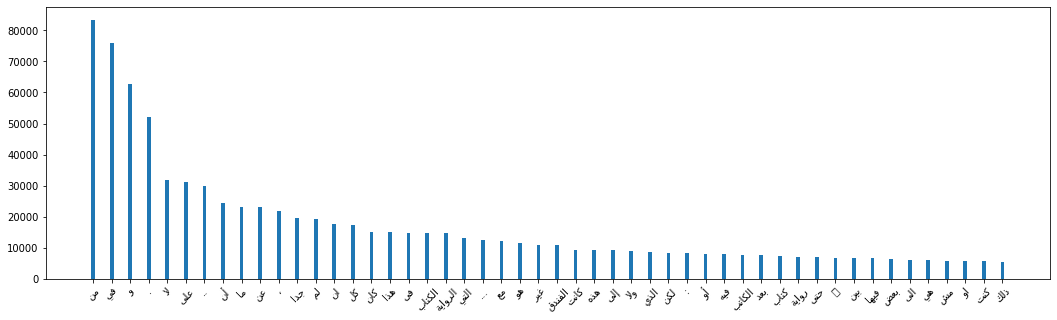

In [70]:
get_vocab_histogram(counts_reviews)

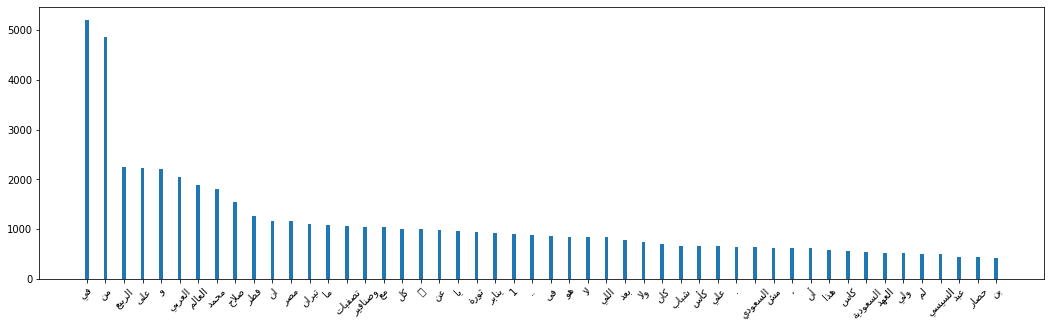

In [71]:
get_vocab_histogram(counts_arsas)